<a href="https://colab.research.google.com/github/ecastrofelix/Proyecto/blob/main/EDA_Migracion_1970_2069.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [24]:
import pandas as pd
import numpy as np


from pathlib import Path

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
DATA_DIR = Path("/content/drive/MyDrive/Colab Notebooks/")
FILE_NAME = "03_mig_interest_quinquenal_proyecciones.csv"
path = DATA_DIR / FILE_NAME

Fuente de datos:
`https://ilostat.ilo.org/es/data/`

Unemployment by sex and age (thousands)|Annual|Labour Force Statistics (LFS)



---



# Exploración Inicial -- Conociendo un conjunto de datos

Importemos un conjunto de datos y revisemos algunos métodos útiles de pandas para la exploración inicial

In [27]:
migracion = pd.read_csv(path,low_memory=False)

In [28]:
print("Filas:", migracion.shape[0])
print("Columnas:", migracion.shape[1])

Filas: 23040
Columnas: 10


### `.head()` -- ¿Qué columnas tienen los datos y qué parecen representar?

In [ ]:
migracion.tail()

,RENGLON,ANIO,ENTIDAD,CVE_GEO,EDAD,SEXO,EMIGRANTES,INMIGRANTES,ENTIDAD_FEDERATIVA,FECHA
23035,23036,2065-2069,Zacatecas,32,75--79,Mujeres,562,400,Zacatecas,2069-01-01
23036,23037,2065-2069,Zacatecas,32,80--84,Hombres,338,284,Zacatecas,2069-01-01
23037,23038,2065-2069,Zacatecas,32,80--84,Mujeres,578,317,Zacatecas,2069-01-01
23038,23039,2065-2069,Zacatecas,32,85--89,Hombres,279,215,Zacatecas,2069-01-01
23039,23040,2065-2069,Zacatecas,32,85--89,Mujeres,479,331,Zacatecas,2069-01-01


In [ ]:
migracion['ENTIDAD_FEDERATIVA'].unique()


array(['Aguascalientes', 'Baja California', 'Baja California Sur',
       'Campeche', 'Coahuila', 'Colima', 'Chiapas', 'Chihuahua',
       'Ciudad de México', 'Durango', 'Guanajuato', 'Guerrero', 'Hidalgo',
       'Jalisco', 'Estado de México', 'Michoacán', 'Morelos', 'Nayarit',
       'Nuevo León', 'Oaxaca', 'Puebla', 'Querétaro', 'Quintana Roo',
       'San Luis Potosí', 'Sinaloa', 'Sonora', 'Tabasco', 'Tamaulipas',
       'Tlaxcala', 'Veracruz', 'Yucatán', 'Zacatecas'], dtype=object)

### `.dtypes` -- ¿Qué tipo de datos contiene el conjunto de datos?

In [ ]:
migracion.dtypes

,0
RENGLON,int64
ANIO,object
ENTIDAD,object
CVE_GEO,int64
EDAD,object
SEXO,object
EMIGRANTES,int64
INMIGRANTES,int64
ENTIDAD_FEDERATIVA,object
FECHA,object


En pandas, que una columna tenga `dtype = object` significa básicamente que:

la columna contiene “objetos de Python”, y en la práctica casi siempre quiere decir que son strings (texto).

### `.info()` -- ¿Qué tan completo está el conjunto de datos y qué tipo de datos contiene?

In [ ]:
migracion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23040 entries, 0 to 23039
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   RENGLON             23040 non-null  int64 
 1   ANIO                23040 non-null  object
 2   ENTIDAD             23040 non-null  object
 3   CVE_GEO             23040 non-null  int64 
 4   EDAD                23040 non-null  object
 5   SEXO                23040 non-null  object
 6   EMIGRANTES          23040 non-null  int64 
 7   INMIGRANTES         23040 non-null  int64 
 8   ENTIDAD_FEDERATIVA  23040 non-null  object
 9   FECHA               23040 non-null  object
dtypes: int64(4), object(6)
memory usage: 1.8+ MB


### `.isna()` -- ¿Qué valores tenemos en columnas categóricas?

In [ ]:
migracion.isna().sum().sort_values(ascending=False).head(10)

,0
RENGLON,0
ANIO,0
ENTIDAD,0
CVE_GEO,0
EDAD,0
SEXO,0
EMIGRANTES,0
INMIGRANTES,0
ENTIDAD_FEDERATIVA,0
FECHA,0


### `.unique()` -- ¿Qué valores tenemos en columnas categóricas?

In [ ]:
migracion['SEXO'].unique()

array(['Hombres', 'Mujeres'], dtype=object)

### `.value_counts()` -- ¿Cuántas valores tenemos en cada categoría en una columna categórica?

In [ ]:
migracion.value_counts("SEXO")

,count
SEXO,
Hombres,11520
Mujeres,11520


### `.describe()` -- ¿Qué podemos decir rápidamente de los datos en las columnas numéricas?

In [ ]:
migracion.describe()

,RENGLON,CVE_GEO,EMIGRANTES,INMIGRANTES
count,23040.000000,23040.000000,23040.000000,23040.000000
mean,11520.500000,16.500000,3549.068707,3549.068707
std,6651.219437,9.233293,6343.223256,5760.188415
min,1.000000,1.000000,0.000000,3.000000
25%,5760.750000,8.750000,473.000000,570.750000
50%,11520.500000,16.500000,1633.000000,1918.000000
75%,17280.250000,24.250000,4147.500000,4317.000000
max,23040.000000,32.000000,141032.000000,147897.000000


### Histogramas

Los histogramas son una forma clásica de analizar la distribución de datos numéricos: dividen los valores en intervalos (bins) y muestran cuántos datos caen en cada uno.

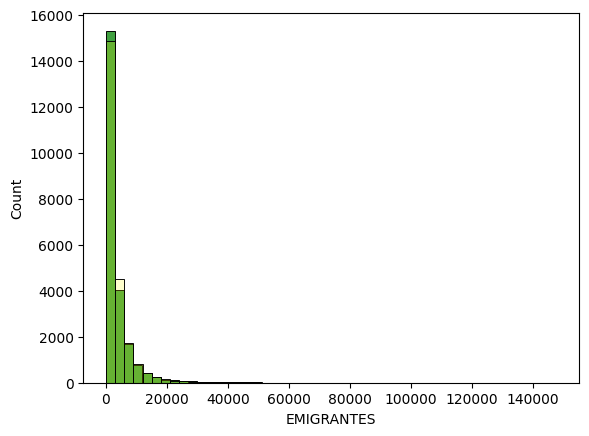

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

#data = migracion['EMIGRANTES']

# binwidth controla la resolución del histograma,
# ajustando qué tan finos o gruesos son los intervalos de agrupación
sns.histplot(data=migracion, x='EMIGRANTES', binwidth=3000, color='green')
sns.histplot(data=migracion, x='INMIGRANTES', binwidth=3000, color='yellow', alpha=0.2)

plt.show()

# Validación de datos

La validación de datos es un paso inicial importante en el análisis exploratorio de datos (EDA).

Queremos entender si los tipos de datos y sus rangos son los esperados antes de avanzar demasiado en nuestro análisis.

## Actualización de tipos de datos

## Validando datos numéricos

## .select_dtypes("number")

Podemos seleccionar y visualizar únicamente las columnas numéricas de un DataFrame.

In [ ]:
migracion.select_dtypes("number")

,RENGLON,CVE_GEO,EMIGRANTES,INMIGRANTES
0,1,1,2597,3470
1,2,1,2567,3308
2,3,1,1137,2042
3,4,1,1136,1962
4,5,1,1041,1836
...,...,...,...,...
23035,23036,32,562,400
23036,23037,32,338,284
23037,23038,32,578,317
23038,23039,32,279,215


### `.min` y  `.max`

In [ ]:
print(migracion['EMIGRANTES'].max())

print(migracion['EMIGRANTES'].min())

141032
0


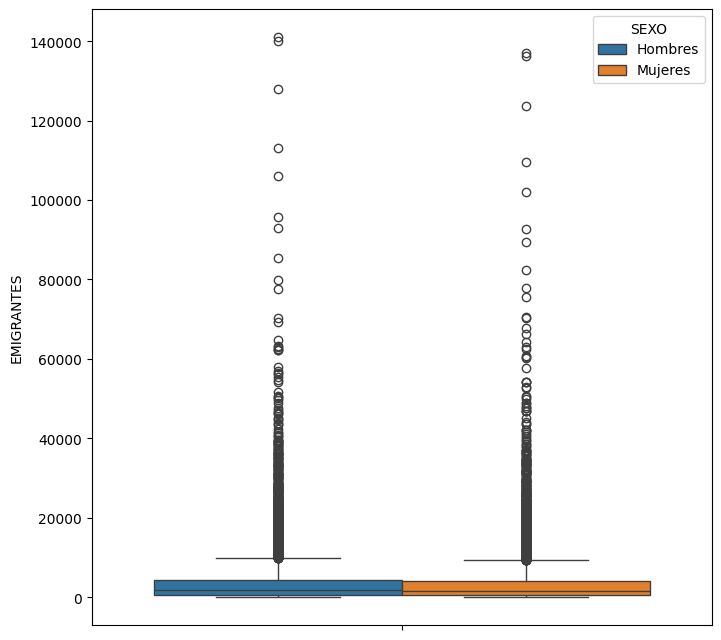

In [ ]:
plt.figure(figsize=(8, 8))
sns.boxplot(data=migracion, y='EMIGRANTES', hue='SEXO')
plt.show()

In [ ]:
migracion.EMIGRANTES.describe()

,EMIGRANTES
count,23040.000000
mean,3549.068707
std,6343.223256
min,0.000000
25%,473.000000
50%,1633.000000
75%,4147.500000
max,141032.000000


# Agregación de datos

### .groupby()

Podemos explorar con mayor detalle las características de subconjuntos de datos con ayuda de la función .groupby(), que agrupa los datos según una categoría determinada, permitiendo al usuario encadenar una función de agregación como .mean() o .count() para describir los datos dentro de cada grupo.

In [ ]:
data = migracion[ migracion['ENTIDAD_FEDERATIVA'] == 'Guerrero']

In [ ]:
data['EDAD'].unique()

array(['00--04', '05--09', '10--14', '15--19', '20--24', '25--29',
       '30--34', '35--39', '40--44', '45--49', '50--54', '55--59',
       '60--64', '65--69', '70--74', '75--79', '80--84', '85--89'],
      dtype=object)

In [ ]:
data_slice2 = data[data['EDAD'].isin([
    '00--04',
    '85--89'
])]


In [ ]:
data_slice2.head()

,RENGLON,ANIO,ENTIDAD,CVE_GEO,EDAD,SEXO,EMIGRANTES,INMIGRANTES,ENTIDAD_FEDERATIVA,FECHA
396,397,1970-1974,Guerrero,12,00--04,Hombres,13662,6850,Guerrero,1974-01-01
397,398,1970-1974,Guerrero,12,00--04,Mujeres,13625,6621,Guerrero,1974-01-01
430,431,1970-1974,Guerrero,12,85--89,Hombres,36,20,Guerrero,1974-01-01
431,432,1970-1974,Guerrero,12,85--89,Mujeres,43,29,Guerrero,1974-01-01
1548,1549,1975-1979,Guerrero,12,00--04,Hombres,3428,1726,Guerrero,1979-01-01
